# Fourier Optics Lab — Reproducible Data Analysis
This notebook reproduces the quantitative results reported in `report/main.pdf` using the raw measurements stored under `data/raw/`.

**Focus:** regression, uncertainty propagation, and an uncertainty budget (random vs systematic).

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

ROOT = Path('..').resolve()
DATA_RAW = ROOT / 'data' / 'raw'
DATA_PROCESSED = ROOT / 'data' / 'processed'
OUT = ROOT / 'analysis' / 'output'

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)

Matplotlib created a temporary cache directory at /tmp/matplotlib-_uucclmm because the default path (/home/oai/.config/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


ROOT: /mnt/data/FourierOpticsLab_GitHub


## Load raw data

In [2]:
screen = pd.read_csv(DATA_RAW / 'screen_angle.csv')
camera = pd.read_csv(DATA_RAW / 'camera_calibration.csv')
slit = pd.read_csv(DATA_RAW / 'slit_cutoff.csv')
abbe = pd.read_csv(DATA_RAW / 'abbe_params.csv')

screen, camera, slit, abbe

(   L_cm  y_cm  sigma_L_cm  sigma_y_cm  order_m
 0     5   0.3         0.1        0.05        1
 1     8   0.4         0.1        0.05        1
 2    12   0.7         0.1        0.05        1
 3    18   1.0         0.1        0.05        1,
    cal_spacing_mm  cal_pixels_px  sigma_cal_pixels_px  count_pixels_px  \
 0            0.74           1016                    2             1280   
 
    periods_count_P  sigma_periods_count_P  
 0               94                      1  ,
    f_obj_mm  lambda_nm  w_min_in  sigma_w_min_in
 0      30.0      550.0      0.12          0.0005,
    D_mm   f_mm  lambda_nm    n  F1_um  F2_um
 0  25.4  150.0      550.0  1.0    4.0    6.0)

## Experiment 1(i): screen-angle method
We fit a **through-origin** model $y = m L$ so that $m = \tan\theta$.

In [3]:
L = screen['L_cm'].to_numpy(float)
y = screen['y_cm'].to_numpy(float)

m = float(np.sum(L*y)/np.sum(L**2))
res = y - m*L
N = len(L)

sigma_m = math.sqrt(float(np.sum(res**2) / ((N-1) * np.sum(L**2))))
R2 = 1.0 - float(np.sum(res**2))/float(np.sum(y**2))

theta = math.atan(m)
sigma_theta = sigma_m/(1+m**2)

lam = 550e-9
# d = lambda / sin(theta)
d = lam / math.sin(theta)
sigma_d = abs(lam*math.cos(theta)/(math.sin(theta)**2)) * sigma_theta

print('m = tan(theta) =', m, '+/-', sigma_m)
print('theta =', theta, '+/-', sigma_theta, 'rad')
print('R^2 =', R2)
print('d_screen =', d*1e6, '+/-', sigma_d*1e6, 'um')

m = tan(theta) = 0.05583482944344703 +/- 0.0014548468918184568
theta = 0.05577691551583995 +/- 0.0014503254613240887 rad
R^2 = 0.9979673538455189
d_screen = 9.865824944744606 +/- 0.2562675888322022 um


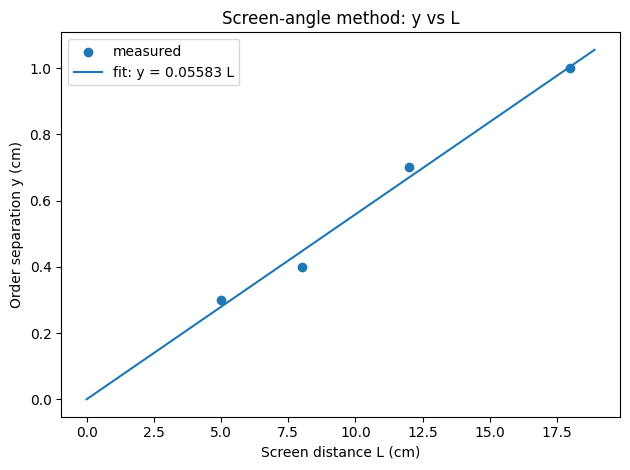

In [4]:
# Plot y vs L with fit
L_line = np.linspace(0, L.max()*1.05, 200)
y_line = m*L_line

plt.figure()
plt.scatter(L, y, label='measured')
plt.plot(L_line, y_line, label=f'fit: y = {m:.5f} L')
plt.xlabel('Screen distance L (cm)')
plt.ylabel('Order separation y (cm)')
plt.title('Screen-angle method: y vs L')
plt.legend()
plt.tight_layout()
plt.show()

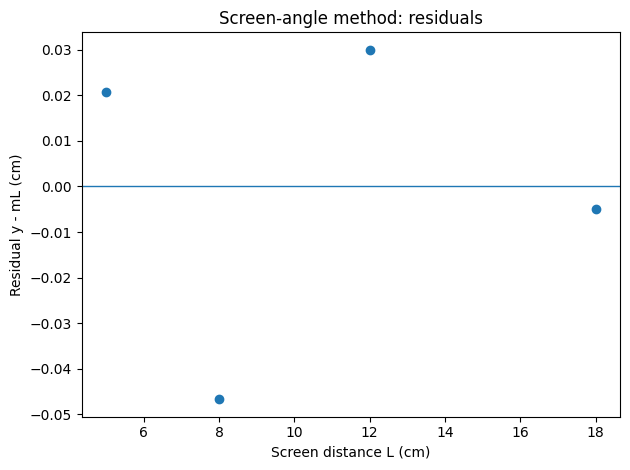

In [5]:
# Residuals
plt.figure()
plt.axhline(0, linewidth=1)
plt.scatter(L, res)
plt.xlabel('Screen distance L (cm)')
plt.ylabel('Residual y - mL (cm)')
plt.title('Screen-angle method: residuals')
plt.tight_layout()
plt.show()

## Experiment 1(ii): calibrated camera method
We calibrate an **object-plane** scale factor using a known spacing of 0.74 mm, then count periods in pixels.

In [6]:
row = camera.iloc[0]

dx_um = float(row['cal_spacing_mm'])*1e3

dp = float(row['cal_pixels_px'])
sig_dp = float(row['sigma_cal_pixels_px'])

Npx = float(row['count_pixels_px'])
P = float(row['periods_count_P'])
sig_P = float(row['sigma_periods_count_P'])

s = dx_um/dp
sig_s = s*(sig_dp/dp)

# d = s*N/P

d_cam = s*Npx/P
sig_d_cam = d_cam*math.sqrt((sig_s/s)**2 + (sig_P/P)**2)

print('s =', s, '+/-', sig_s, 'um/px')
print('d_cam =', d_cam, '+/-', sig_d_cam, 'um')
print('dominant rel. term:', (sig_P/P)*100, '% (period count)')

s = 0.7283464566929134 +/- 0.0014337528675057352 um/px
d_cam = 9.917909197520522 +/- 0.10730077255170278 um
dominant rel. term: 1.0638297872340425 % (period count)


## Experiment 1(iii): Fourier-plane slit cutoff
Random error from knob ticks is small, but the method is typically **systematics-dominated** (threshold + centering).

In [7]:
row = slit.iloc[0]

f = float(row['f_obj_mm'])*1e-3
w_in = float(row['w_min_in'])
sig_w_in = float(row['sigma_w_min_in'])

inch = 0.0254
w = w_in*inch
sig_w = sig_w_in*inch

lam = 550e-9

d_slit = 2*f*lam/w
sig_d_slit = d_slit*(sig_w/w)

print('d_slit (random only) =', d_slit*1e6, '+/-', sig_d_slit*1e6, 'um')

# Cross-check: what w would be implied by d_cam?
w_true = 2*f*lam/(d_cam*1e-6)
w_true_in = w_true/inch

print('w_true implied by camera d =', w_true_in, 'in')
print('Δw = w_true - w_measured =', w_true_in - w_in, 'in')
print('mis-centering scale δ ~ |Δw|/2 =', abs(w_true_in-w_in)*inch*1e3/2, 'mm')

d_slit (random only) = 10.826771653543307 +/- 0.045111548556430445 um
w_true implied by camera d = 0.13099662162162162 in
Δw = w_true - w_measured = 0.010996621621621627 in
mis-centering scale δ ~ |Δw|/2 = 0.13965709459459466 mm


## Experiment 2: Abbe diffraction limit estimate

In [8]:
row = abbe.iloc[0]
D = float(row['D_mm'])*1e-3
f_abbe = float(row['f_mm'])*1e-3
n = float(row['n'])

NA = n*(D/(2*f_abbe))
dx_min = 0.61*lam/NA

print('NA ≈', NA)
print('Δx_min ≈', dx_min*1e6, 'um')
print('Targets:', row['F1_um'], 'um (F1),', row['F2_um'], 'um (F2)')

NA ≈ 0.08466666666666667
Δx_min ≈ 3.96259842519685 um
Targets: 4.0 um (F1), 6.0 um (F2)


## Summary table (Experiment 1)
These should match the values quoted in the report.

In [9]:
summary = pd.DataFrame([
    {'method': 'screen', 'd_um': d*1e6, 'sigma_rand_um': sigma_d*1e6},
    {'method': 'camera', 'd_um': d_cam, 'sigma_rand_um': sig_d_cam},
    {'method': 'slit', 'd_um': d_slit*1e6, 'sigma_rand_um': sig_d_slit*1e6},
])
summary

,method,d_um,sigma_rand_um
0,screen,9.865825,0.256268
1,camera,9.917909,0.107301
2,slit,10.826772,0.045112


In [10]:
# Save machine-readable results
summary.to_csv(DATA_PROCESSED/'grating_results.csv', index=False)

print('Wrote:', DATA_PROCESSED/'grating_results.csv')

Wrote: /mnt/data/FourierOpticsLab_GitHub/data/processed/grating_results.csv


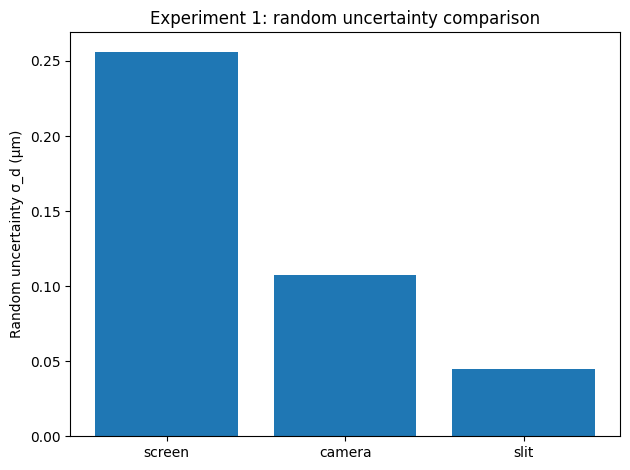

In [11]:
# Uncertainty comparison plot
plt.figure()
plt.bar(summary['method'], summary['sigma_rand_um'])
plt.ylabel('Random uncertainty σ_d (µm)')
plt.title('Experiment 1: random uncertainty comparison')
plt.tight_layout()
plt.show()

## Notes on systematics
Random uncertainty (repeatability) decreases with averaging. **Systematic uncertainty** is a bias that does not average down.

Examples in this lab:
- wavelength uncertainty from the finite bandpass filter (affects the screen/slit methods)
- camera calibration target spacing tolerance (scale-factor bias)
- slit mis-centering and the subjective `just-visible` cutoff criterion